# 04 - Extras: Value Prediction, Aging Curves, and Moneyball

This notebook explores three "creative extras" built on top of `players_merged.csv`
(EA FC 26 attributes merged with Transfermarkt market values and Sofascore ratings):

1. **Value prediction** - train a model that predicts real-world Transfermarkt
   `market_value_eur` from FC26 in-game attributes.
2. **Aging curves** - how overall rating and pace evolve with age, split by
   position group, using the full 18k-player FC26 dataset.
3. **Moneyball / undervalued players** - use the value-prediction model to
   flag players whose actual market value looks cheap relative to what their
   FC26 attributes suggest.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

df = pd.read_csv("../data/processed/players_merged.csv")
print(df.shape)
df.head(3)


(18405, 41)


,player_id,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,league_name,league_level,club_name,club_position,nationality_name,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,pace,shooting,passing,dribbling,defending,physic,name_norm,tm_match_score,ss_match_score,market_value_eur,position_tm,foot_tm,contract_until,tm_league,sofascore_rating,sofascore_appearances,sofascore_minutes,ss_league
0,252371,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",90,94,174500000,320000,22,2003-06-29,186,75,La Liga,1.0,Real Madrid,CAM,England,Right,4,4,5,NaN,Normal (170-185),80.0,86.0,83.0,90.0,78.0,85.0,jude victor william bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,239053,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,120500000,340000,26,1998-07-22,182,74,La Liga,1.0,Real Madrid,RDM,Uruguay,Right,4,3,4,NaN,Unique,88.0,84.0,84.0,84.0,83.0,85.0,federico santiago valverde dipetta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,212622,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",89,89,86000000,140000,30,1995-02-08,177,75,Bundesliga,1.0,FC Bayern München,RDM,Germany,Right,4,3,4,NaN,Normal (170-185),72.0,74.0,89.0,84.0,83.0,79.0,joshua walter kimmich,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Position groups

FC26 lists multiple eligible positions per player (`player_positions`), e.g. `"CAM, CM"`.
We take the **first listed position** as the primary position and map it to a coarse
position group used throughout the notebook.


In [2]:
POSITION_GROUP = {
    "GK": "Goalkeeper",
    "CB": "Defender", "LCB": "Defender", "RCB": "Defender",
    "LB": "Defender", "RB": "Defender", "LWB": "Defender", "RWB": "Defender",
    "CDM": "Midfielder", "LDM": "Midfielder", "RDM": "Midfielder",
    "CM": "Midfielder", "LCM": "Midfielder", "RCM": "Midfielder",
    "CAM": "Midfielder", "LAM": "Midfielder", "RAM": "Midfielder",
    "LM": "Midfielder", "RM": "Midfielder",
    "LW": "Attacker", "RW": "Attacker",
    "CF": "Attacker", "LF": "Attacker", "RF": "Attacker",
    "ST": "Attacker", "LS": "Attacker", "RS": "Attacker",
}

def primary_position(pos_str):
    if pd.isna(pos_str):
        return np.nan
    return str(pos_str).split(",")[0].strip()

df["primary_position"] = df["player_positions"].apply(primary_position)
df["position_group"] = df["primary_position"].map(POSITION_GROUP)

print(df["position_group"].value_counts(dropna=False))


position_group
Midfielder    6864
Defender      6116
Attacker      3363
Goalkeeper    2062
Name: count, dtype: int64


## Part 1 - Value prediction

Train a gradient-boosted regression tree to predict `market_value_eur` (log-transformed,
since market values are heavily right-skewed) from FC26 attributes. We restrict training
to rows with a known market value **and** a high-confidence Transfermarkt name match
(`tm_match_score >= 90`), so the model learns from clean labels only.


In [3]:
FEATURES_NUM = [
    "overall", "potential", "age",
    "pace", "shooting", "passing", "dribbling", "defending", "physic",
    "league_level",
]
FEATURES_CAT = ["position_group"]

model_df = df[
    df["market_value_eur"].notna() & (df["tm_match_score"] >= 90)
].copy()

# Outfield attribute columns are NaN for goalkeepers - fill with 0 (GK doesn't
# use these skills) rather than dropping ~5% of the training rows.
for c in ["pace", "shooting", "passing", "dribbling", "defending", "physic"]:
    model_df[c] = model_df[c].fillna(0)

model_df = model_df.dropna(subset=FEATURES_NUM + FEATURES_CAT + ["market_value_eur"])
model_df["log_value"] = np.log1p(model_df["market_value_eur"])

print(f"Training rows: {len(model_df)}")
model_df[FEATURES_NUM + FEATURES_CAT + ["market_value_eur"]].describe(include="all").T


Training rows: 1636


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
overall,1636.0,NaN,NaN,NaN,69.828851,6.953849,50.0,65.0,70.0,75.0,89.0
potential,1636.0,NaN,NaN,NaN,76.43643,5.509424,58.0,73.0,77.0,80.0,92.0
age,1636.0,NaN,NaN,NaN,23.955379,4.307716,16.0,21.0,23.0,27.0,41.0
pace,1636.0,NaN,NaN,NaN,60.341076,24.778402,0.0,58.0,68.0,75.0,94.0
shooting,1636.0,NaN,NaN,NaN,48.629584,23.092945,0.0,36.0,55.0,66.0,89.0
passing,1636.0,NaN,NaN,NaN,53.791565,22.613978,0.0,50.0,60.0,68.0,92.0
dribbling,1636.0,NaN,NaN,NaN,58.398533,23.951508,0.0,57.0,66.0,73.0,90.0
defending,1636.0,NaN,NaN,NaN,48.733496,24.482307,0.0,31.0,58.0,68.0,88.0
physic,1636.0,NaN,NaN,NaN,57.959046,23.746163,0.0,56.0,66.0,73.0,88.0
league_level,1636.0,NaN,NaN,NaN,1.176039,0.410341,1.0,1.0,1.0,1.0,3.0


In [4]:
X = model_df[FEATURES_NUM + FEATURES_CAT]
y = model_df["log_value"]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, model_df.index, test_size=0.2, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ],
    remainder="passthrough",
)

gbr = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)

pipe = Pipeline([("prep", preprocess), ("model", gbr)])
pipe.fit(X_train, y_train)

pred_log = pipe.predict(X_test)
pred_eur = np.expm1(pred_log)
actual_eur = np.expm1(y_test)

r2 = r2_score(y_test, pred_log)
mae_log = mean_absolute_error(y_test, pred_log)
mae_eur = mean_absolute_error(actual_eur, pred_eur)

print(f"Holdout R^2 (log-value space): {r2:.3f}")
print(f"Holdout MAE (log-value space): {mae_log:.3f}")
print(f"Holdout MAE (EUR, back-transformed): EUR {mae_eur:,.0f}")


Holdout R^2 (log-value space): 0.665
Holdout MAE (log-value space): 0.675
Holdout MAE (EUR, back-transformed): EUR 4,078,765


### Feature importance

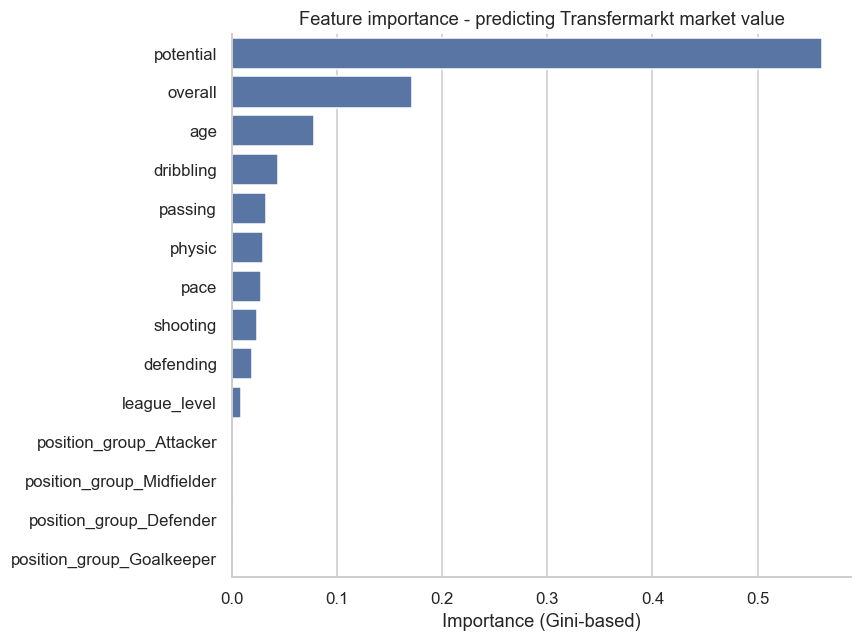

,feature,importance
5,potential,0.560957
4,overall,0.171104
6,age,0.078647
10,dribbling,0.043949
9,passing,0.033126
12,physic,0.029535
7,pace,0.028198
8,shooting,0.024183
11,defending,0.019229
13,league_level,0.009114


In [5]:
feature_names = (
    list(pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(FEATURES_CAT))
    + FEATURES_NUM
)
importances = pipe.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df, y="feature", x="importance", ax=ax, color=PALETTE[0])
ax.set_title("Feature importance - predicting Transfermarkt market value")
ax.set_xlabel("Importance (Gini-based)")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

imp_df


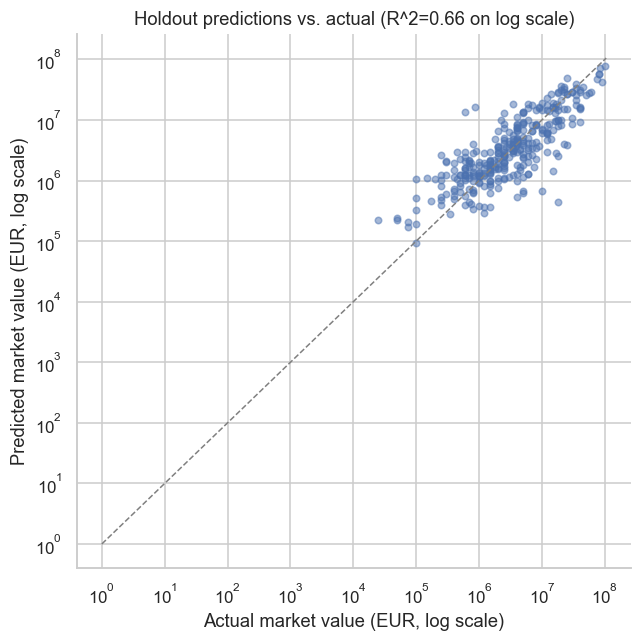

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual_eur, pred_eur, alpha=0.5, s=18, color=PALETTE[0])
lims = [1, max(actual_eur.max(), pred_eur.max()) * 1.05]
ax.plot(lims, lims, ls="--", color="gray", lw=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual market value (EUR, log scale)")
ax.set_ylabel("Predicted market value (EUR, log scale)")
ax.set_title(f"Holdout predictions vs. actual (R^2={r2:.2f} on log scale)")
fig.tight_layout()
plt.show()


## Part 2 - Aging curves

Using the **full** 18k-player FC26 dataset (no TM/Sofascore match needed), we look at how
`overall` and `pace` trend with age, both league-wide and split by position group. Pace is
the attribute most commonly cited as decaying earliest with age, so it's worth isolating.


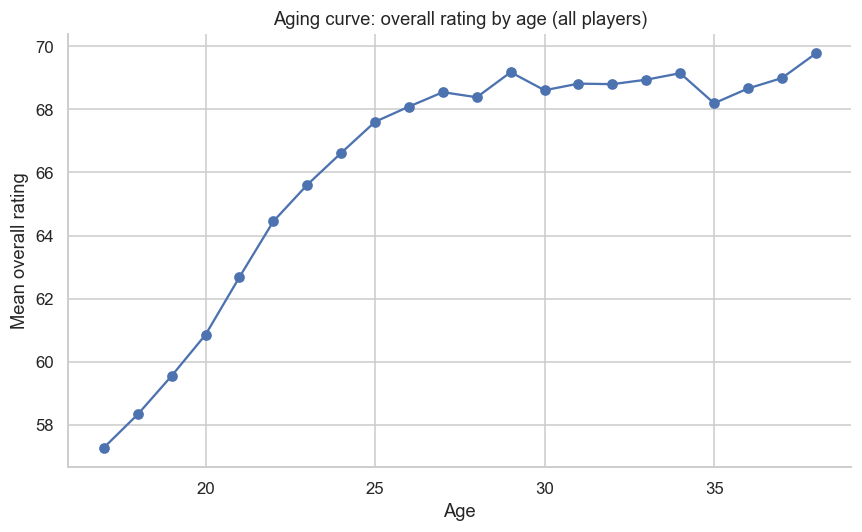

In [7]:
AGE_MIN, AGE_MAX = 17, 38
age_df = df[(df["age"] >= AGE_MIN) & (df["age"] <= AGE_MAX)].copy()

# Overall curve, league-wide
counts_all = age_df.groupby("age").size()
overall_by_age = age_df.groupby("age")["overall"].mean()
overall_by_age = overall_by_age[counts_all >= 5]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(overall_by_age.index, overall_by_age.values, marker="o", color=PALETTE[0])
ax.set_xlabel("Age")
ax.set_ylabel("Mean overall rating")
ax.set_title("Aging curve: overall rating by age (all players)")
fig.tight_layout()
plt.show()


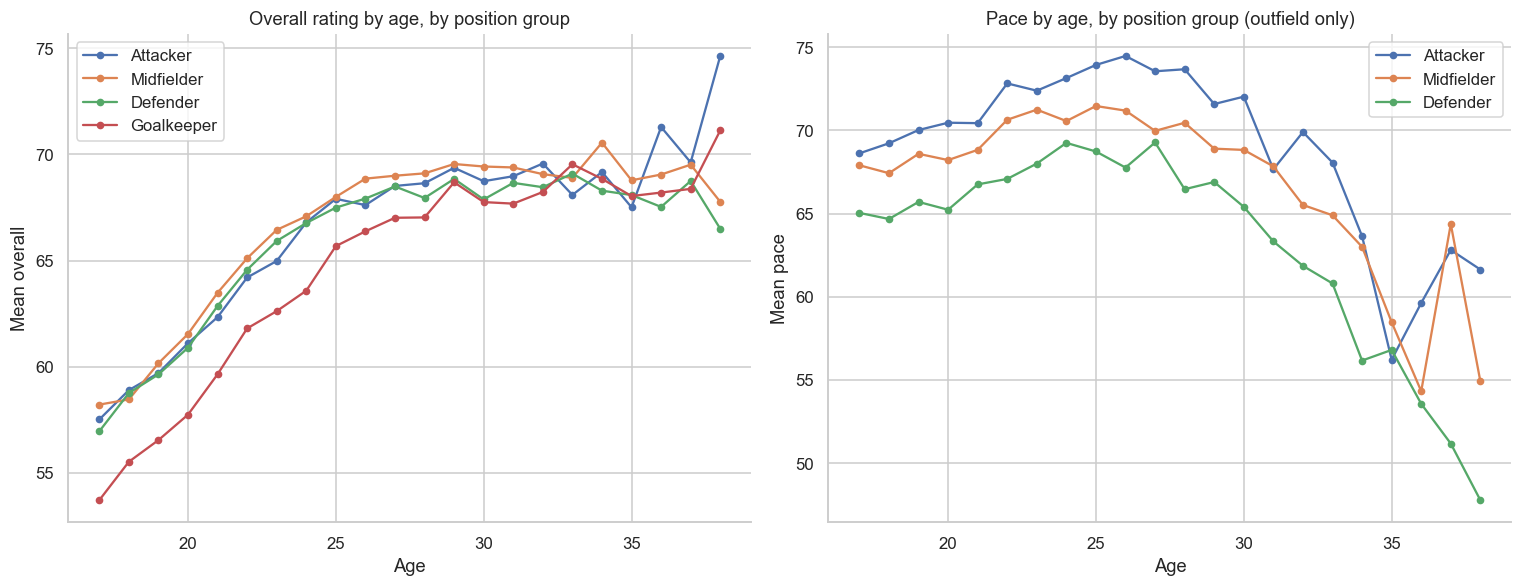

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

group_order = ["Attacker", "Midfielder", "Defender", "Goalkeeper"]
plot_df = age_df.dropna(subset=["position_group"])

for i, (metric, title) in enumerate(
    [("overall", "Overall rating by age, by position group"),
     ("pace", "Pace by age, by position group (outfield only)")]
):
    ax = axes[i]
    sub = plot_df if metric == "overall" else plot_df[plot_df["position_group"] != "Goalkeeper"]
    groups = group_order if metric == "overall" else ["Attacker", "Midfielder", "Defender"]
    for grp, color in zip(groups, PALETTE):
        grp_sub = sub[sub["position_group"] == grp]
        counts = grp_sub.groupby("age").size()
        g = grp_sub.groupby("age")[metric].mean()
        g = g[counts >= 5]
        ax.plot(g.index, g.values, marker="o", markersize=4, label=grp, color=color)
    ax.set_xlabel("Age")
    ax.set_ylabel(f"Mean {metric}")
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
plt.show()


Pace typically peaks in the early-to-mid 20s and declines earlier/faster than
overall rating, which is often propped up by rising `passing`/`defending`/experience-driven
attributes even as raw speed fades - especially visible for defenders and midfielders,
who can sustain overall rating into their 30s despite pace loss.


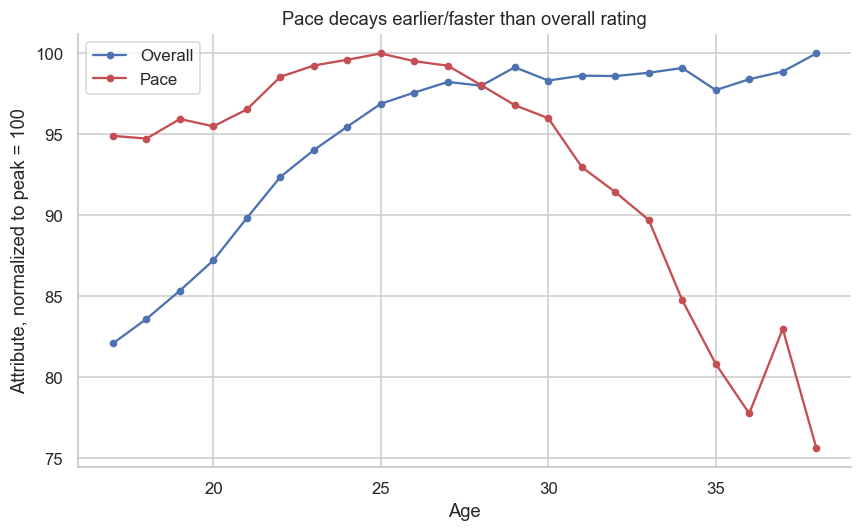

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for metric, color, label in [("overall", PALETTE[0], "Overall"), ("pace", PALETTE[3], "Pace")]:
    sub = age_df.dropna(subset=[metric])
    counts = sub.groupby("age").size()
    g = sub.groupby("age")[metric].mean()
    g = g[counts >= 5]
    # normalize to peak = 100 for shape comparison
    g_norm = 100 * g / g.max()
    ax.plot(g_norm.index, g_norm.values, marker="o", markersize=4, color=color, label=label)

ax.set_xlabel("Age")
ax.set_ylabel("Attribute, normalized to peak = 100")
ax.set_title("Pace decays earlier/faster than overall rating")
ax.legend()
fig.tight_layout()
plt.show()


## Part 3 - Moneyball: undervalued players

Using the value-prediction model from Part 1, we compute a predicted market value for every
player in the training-eligible pool (known market value, high-confidence TM match) and rank
players by how far their **actual** value falls below the **predicted** value. A large negative
gap (`actual - predicted`) suggests a player whose FC26 attributes imply a higher market value
than the market currently assigns - i.e. a possible bargain.


In [10]:
model_df["predicted_value_eur"] = np.expm1(pipe.predict(model_df[FEATURES_NUM + FEATURES_CAT]))
model_df["value_gap_eur"] = model_df["market_value_eur"] - model_df["predicted_value_eur"]
model_df["value_gap_pct"] = model_df["value_gap_eur"] / model_df["predicted_value_eur"]

bargains = model_df.sort_values("value_gap_pct").head(20)

display_cols = [
    "short_name", "age", "position_group", "primary_position", "league_name",
    "overall", "potential", "market_value_eur", "predicted_value_eur", "value_gap_pct",
]
bargains_display = bargains[display_cols].copy()
bargains_display["market_value_eur"] = bargains_display["market_value_eur"].map(lambda v: f"EUR {v:,.0f}")
bargains_display["predicted_value_eur"] = bargains_display["predicted_value_eur"].map(lambda v: f"EUR {v:,.0f}")
bargains_display["value_gap_pct"] = bargains_display["value_gap_pct"].map(lambda v: f"{v:.0%}")
bargains_display = bargains_display.rename(columns={
    "short_name": "Player", "age": "Age", "position_group": "Pos. group",
    "primary_position": "Position", "league_name": "League", "overall": "OVR",
    "potential": "POT", "market_value_eur": "Actual value", "predicted_value_eur": "Model value",
    "value_gap_pct": "Gap %",
})
bargains_display.reset_index(drop=True)


,Player,Age,Pos. group,Position,League,OVR,POT,Actual value,Model value,Gap %
0,M. Diarra,24,Defender,CB,La Liga,71,77,"EUR 25,000","EUR 2,283,273",-99%
1,S. Esposito,22,Attacker,ST,Serie A,75,82,"EUR 600,000","EUR 13,736,626",-96%
2,J. Gower,20,Midfielder,CM,Primeira Liga,66,80,"EUR 100,000","EUR 2,280,460",-96%
3,P. Schuurs,25,Defender,CB,Serie A,77,82,"EUR 850,000","EUR 16,342,952",-95%
4,G. Rahajaän,17,Midfielder,CM,Eredivisie,59,79,"EUR 100,000","EUR 1,073,786",-91%
5,I. Camara,20,Midfielder,CDM,Allsvenskan,64,77,"EUR 250,000","EUR 2,650,828",-91%
6,D. Verduin,21,Goalkeeper,GK,Eredivisie,57,67,"EUR 25,000","EUR 225,613",-89%
7,B. Traoré,21,Defender,CB,Ekstraklasa,66,75,"EUR 50,000","EUR 421,974",-88%
8,S. Bouland,19,Defender,CB,Eredivisie,61,74,"EUR 150,000","EUR 1,107,140",-86%
9,Wei Xiangxin,17,Midfielder,RM,Super League,52,67,"EUR 300,000","EUR 2,095,537",-86%


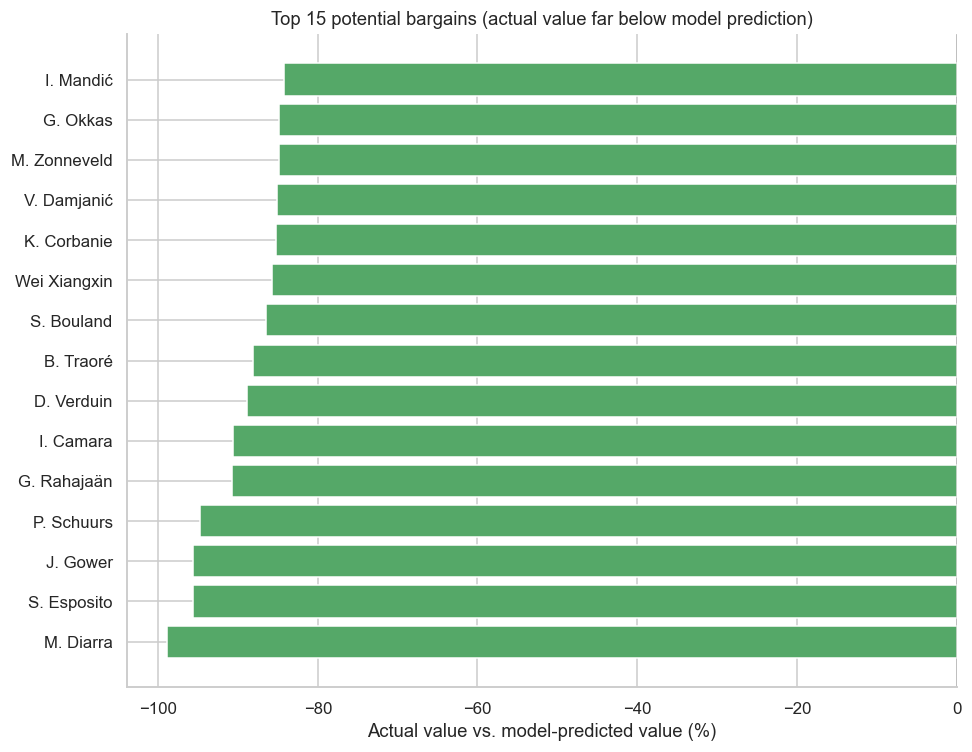

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
top15 = bargains.head(15).sort_values("value_gap_pct")
colors = [PALETTE[2] if v < 0 else PALETTE[3] for v in top15["value_gap_pct"]]
ax.barh(top15["short_name"], top15["value_gap_pct"] * 100, color=colors)
ax.set_xlabel("Actual value vs. model-predicted value (%)")
ax.set_title("Top 15 potential bargains (actual value far below model prediction)")
ax.axvline(0, color="black", lw=0.8)
fig.tight_layout()
plt.show()


### Caveats

- The model only sees FC26 attributes, so it cannot account for real-world factors like
  injury history, contract length, release clauses, transfer-market hype, or club negotiating
  leverage - all of which move actual market value independent of in-game ratings.
- `tm_match_score >= 90` restricts training/scoring to high-confidence name matches, so the
  bargain list is limited to the ~1.6k matched players, not the full 18k-player pool.
- A large gap can also mean the FC26 attributes are simply overrated for that player, not
  that the market is undervaluing them - treat this as a screening tool, not a verdict.
